In [1]:
readout_freq = 10.3
readout_lo_freq = 10.38 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.035 + 0.0023 + 4.8e-5
anharmonicity = 7.72-ge_freq - 9e-4
ge_if_freq = ge_freq-qubit_lo_freq
print(ge_freq, anharmonicity)

fogi_lo_freq = 2 * qubit_lo_freq - readout_lo_freq#
print(fogi_lo_freq)

8.037348 -0.318248
5.3199999999999985


In [2]:
2 * ge_freq + anharmonicity - 10301110000.0e-9

5.421912000000001

In [3]:
qubit_lo_freq = 7.85
ge_freq = 8.012+0.0089-2.8e-05
anharmonicity = 7.682-ge_freq+0.0208-6.5e-4
ge_if_freq = ge_freq-qubit_lo_freq
print(ge_freq, anharmonicity+ge_freq)

8.020872 7.7021500000000005


## 5/29 ef calibration - DPR1-L-120-44_photon

ef_freq =  

ef_pi_amp = 0.875


T1 = 20e-6

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

In [185]:
header = "D:/K_sunada/result/CDY159/"
ef = "/2024-05-29/2024-05-29T172354_c982e1ac-30_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

In [186]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [187]:
Rabi_ef = dd_ef['s11']['values']
#imag_ge = Rabi_ge.imag
amp_ef = dd_ef['amplitude']['values']

I = (Rabi_ef.real)
Q = (Rabi_ef.imag)

PCAef = PCA_transform(I, Q)

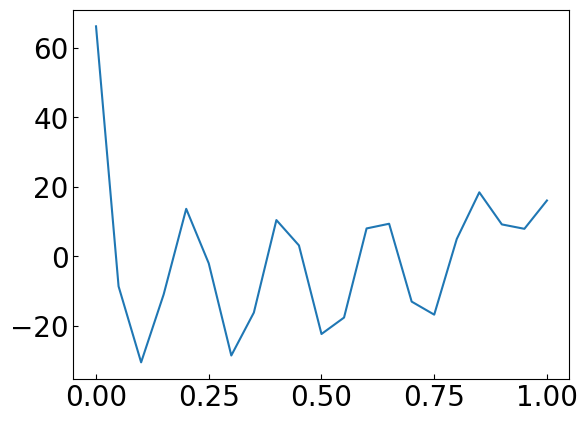

In [188]:
y = PCAef[0]
x = amp_ef

plt.plot(x, y)
plt.show()

In [189]:
par_ini = {
    'amp': 10,
    'phi0':np.pi,
    'detun':1/0.2,
    'const':-5
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [190]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [191]:
result_ef = model.fit(data = y, params = params, delay = x)
result_ef

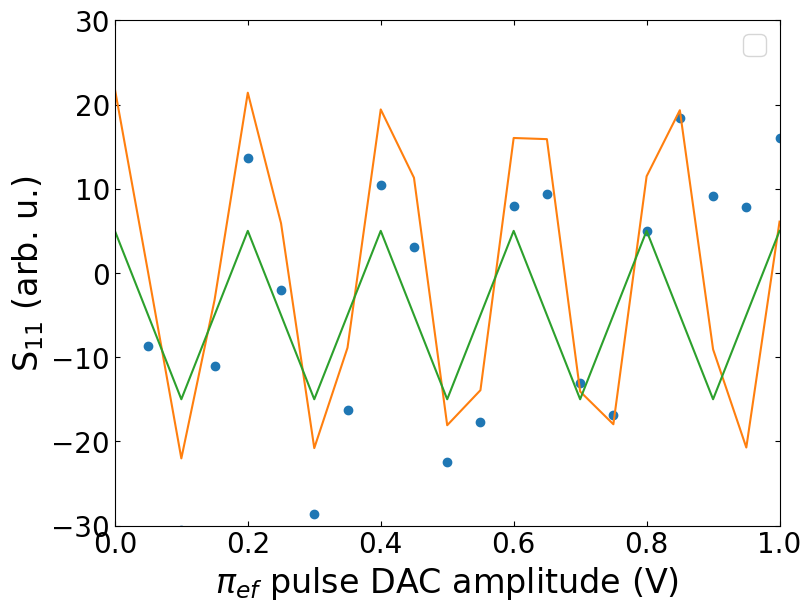

In [192]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ef.plot_fit(ax = ax)
plt.plot(amp_ef,result_ef.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ef}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_ylim(-30, 30)
ax.set_xlim(0, 1.)
# plt.savefig('ef_rabi.png', bbox_inches='tight')
plt.show()

In [193]:
np.pi/(4.78595965*2*np.pi)*5

0.5223612781607969

ramsey

In [177]:
pl = "/2024-05-29/2024-05-29T172041_56a9ba3c-32_ef_T2r1d"
mi = "/2024-05-29/2024-05-29T172144_7bf93f04-32_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [178]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

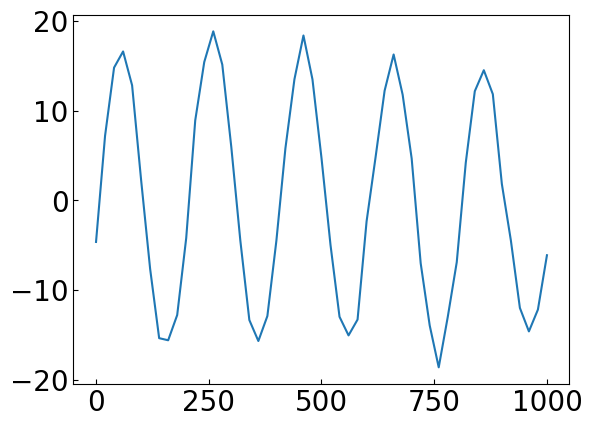

In [179]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2


I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [174]:
par_ini_pl = {
    'amp': 20,
    'phi0':np.pi/2,
    'detun':1/180,
    'const':0.1
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [175]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

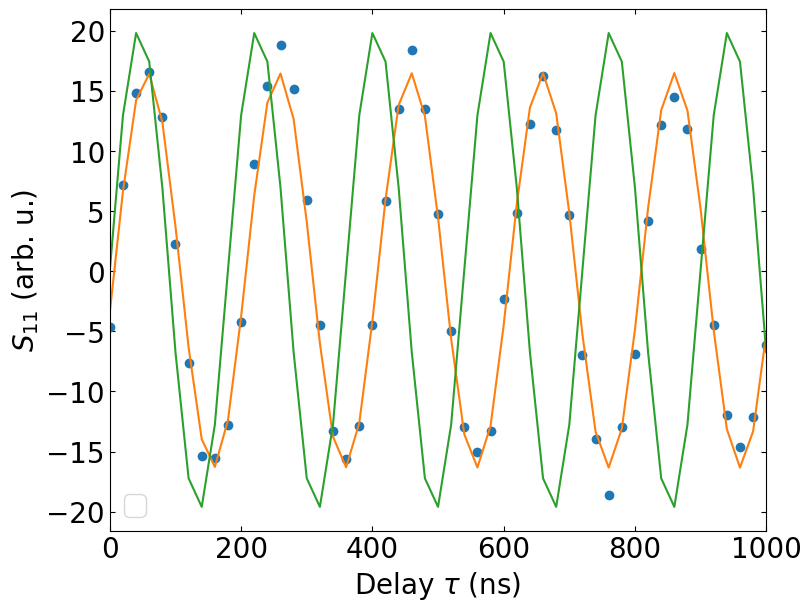

In [176]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)

# plt.title("Rabi(+5MHz)")

# plt.plot(x_pl,result_pl.init_fit)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

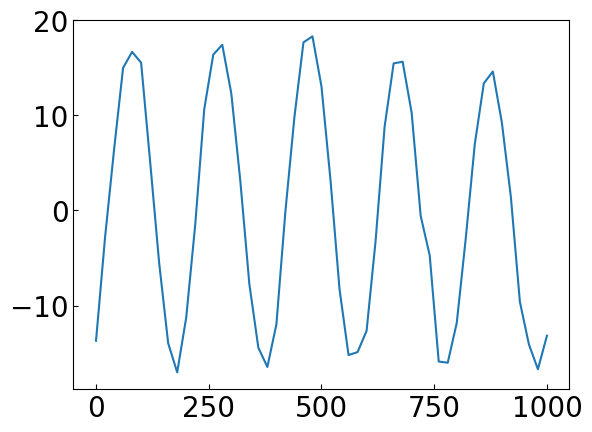

In [180]:
plt.plot(x_mi, y_mi)
plt.show()

In [181]:
par_ini_mi = {
    'amp': 20,
    'phi0': 0,
    'detun':1/200,
    'const':-0.2
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.inf
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [182]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

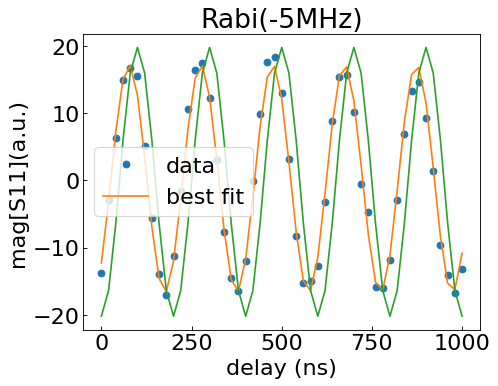

In [183]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_mi.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [184]:
detun = ((0.005-0.00498160)+ (0.00501934-0.005))/2 #GHz
detun

1.8869999999999824e-05

drag

In [214]:
drag = "/2024-05-29/2024-05-29T173000_a3c3623b-31_ef_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-05-29/2024-05-29T173142_e08c931d-31_ef_pi_drag" #n=11
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-05-29/2024-05-29T173241_0368b133-31_ef_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [215]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [216]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [217]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
# x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

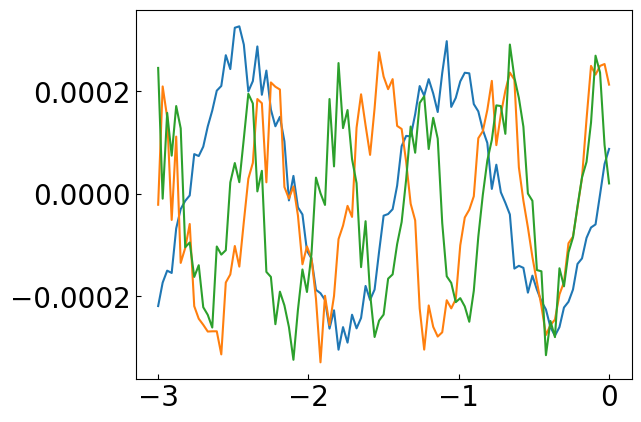

In [218]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [240]:
par_ini= {
    'amp': 0.0003,
    'phi0':np.pi,
    'detun':1/0.6,
    'const':0.
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':0,
    'const':-np.inf
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [241]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [230]:
result0

In [232]:
res0 = (-1.79771557)/(2*np.pi*0.72981830)
res0

-0.3920363729420928

In [237]:
result1

In [239]:
res1 = (-3.22602363)/(2*np.pi*1.32599741)
res1

-0.38720860491406206

In [243]:
result2

In [244]:
res2 = (-4.14690315)/(2*np.pi*1.73533155)
res2

-0.38033085657081006

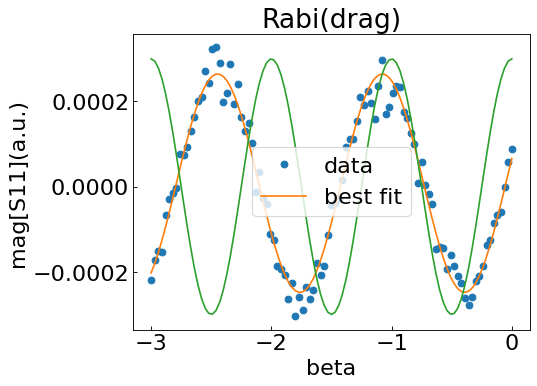

In [228]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)

plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

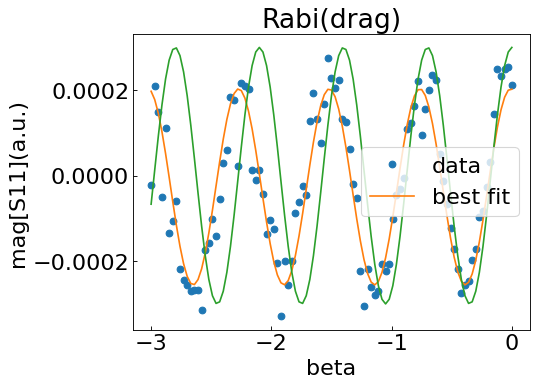

In [235]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

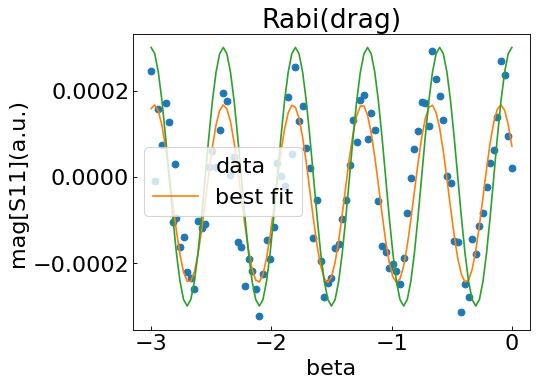

In [242]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


In [245]:
beta = (res0 + res1 + res2)/3
beta

-0.3865252781423216

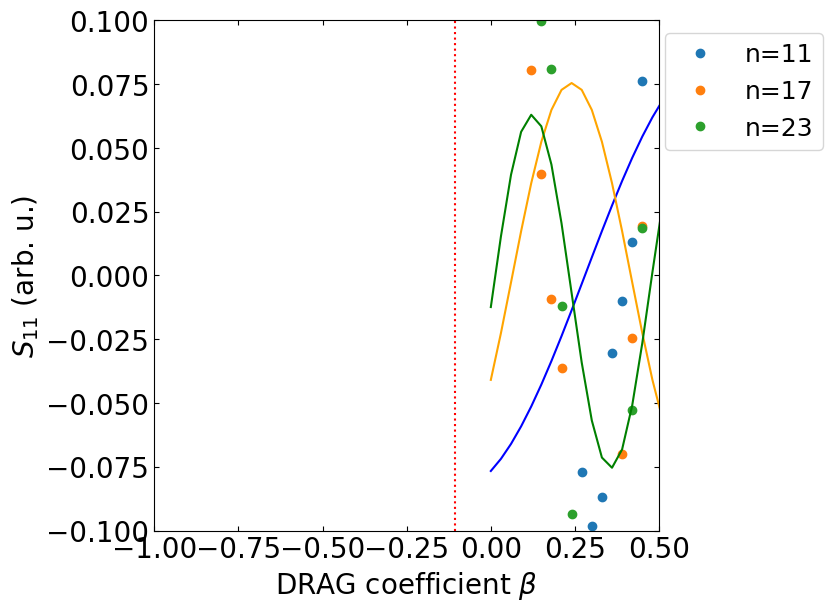

In [74]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.plot(x0, y0*1e3, 'o', label="n=11")
plt.plot(x0, y1*1e3, 'o', label="n=17")
plt.plot(x0, y2*1e3, 'o', label="n=23")
plt.plot(x0, (3.4823e-7-8.4064e-5*np.cos(2*np.pi*0.65672748*x0+0.41313693))*1e3, color='blue')
plt.plot(x0, (-3.5304e-7-7.5781e-5*np.cos(2*np.pi*1.41618906*x0+1.00579675))*1e3, color='orange')
plt.plot(x0, (-6.2264e-6-6.9263e-5*np.cos(2*np.pi*2.14863394*x0+1.4817749))*1e3, color='green')
plt.vlines(-0.10763833733475762, -0.1, 0.1, color='r', linestyles='dotted')
plt.ylim(-0.1, 0.1)

plt.title("")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.xlabel(r"DRAG coefficient ${\beta}$")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(-1, 0.5)
# plt.savefig('drag_ef_pi.png', bbox_inches='tight')

plt.show()

half drag

In [251]:
drag = "/2024-05-29/2024-05-29T173726_adaf59d3-31_ef_pi_drag" #n=11
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2024-05-29/2024-05-29T173820_cde6f519-31_ef_pi_drag" #n=17
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2024-05-29/2024-05-29T173915_ee8eeab2-31_ef_pi_drag" #n=23
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [252]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [253]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [254]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
# x = amp_ef
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

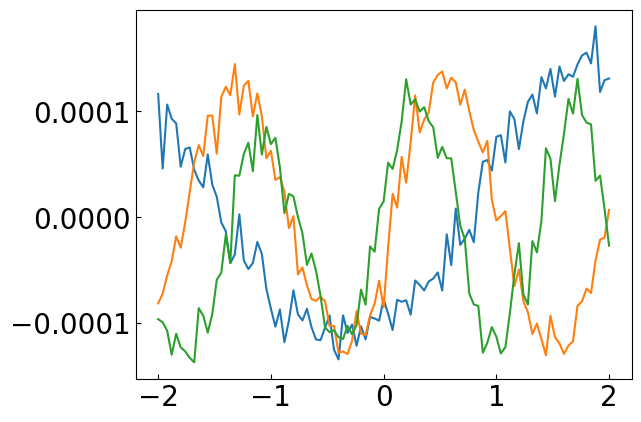

In [255]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [267]:
par_ini= {
    'amp': 1.5e-4,
    'phi0':0,
    'detun':1/1.5,
    'const':-0.00005
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':-np.pi
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [268]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [261]:
result0

In [264]:
res0 = (-0.48336305)/(2*np.pi*0.21761381)
res0

-0.35351441489616386

In [265]:
result1

In [266]:
res1 = (-1.23023793)/(2*np.pi*0.53261113)
res1

-0.367619895098026

In [270]:
result2

In [272]:
res2 = (-1.72351422)/(2*np.pi*0.72515384)
res2

-0.3782725712411209

In [273]:
(res0+res1+res2)/3

-0.3664689604117702

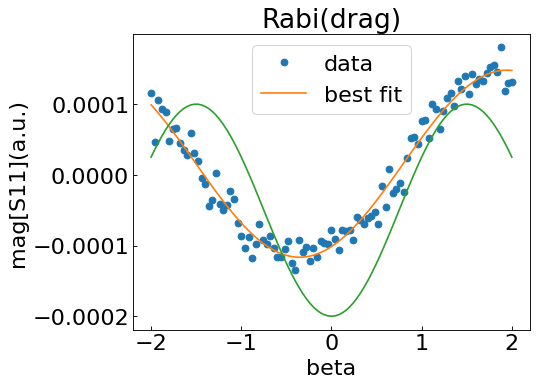

In [258]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

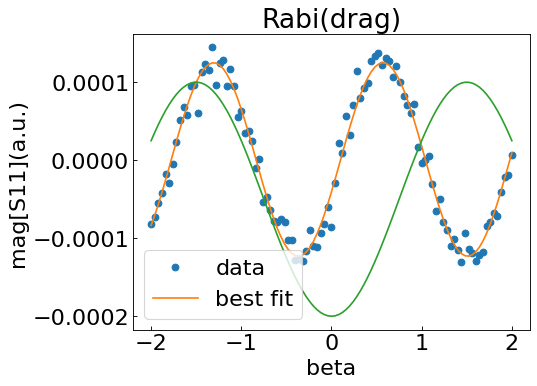

In [259]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

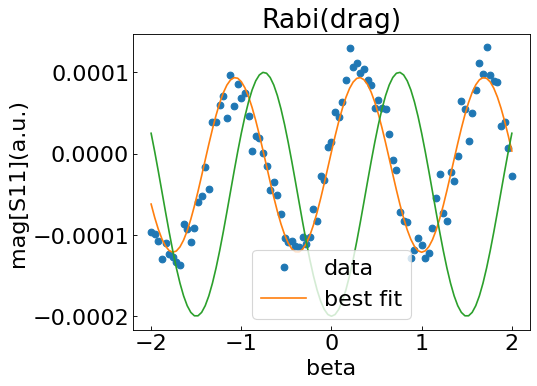

In [269]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


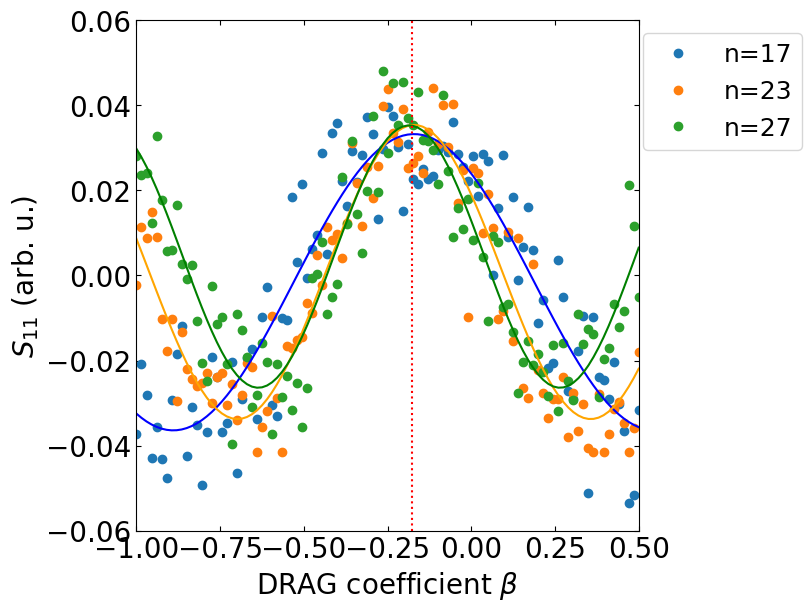

In [85]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'


plt.plot(x0, y1*1e3, 'o', label="n=17")
plt.plot(x0, y2*1e3, 'o', label="n=23")
plt.plot(x0, y0*1e3, 'o', label="n=27")

plt.plot(x0, (-1.5919e-6-3.4841e-5*np.cos(2*np.pi*0.69538804*x0+3.88957417))*1e3, color='blue')
plt.plot(x0, (8.1124e-7-3.4585e-5*np.cos(2*np.pi*0.94793540*x0+4.15857227))*1e3, color='orange')
plt.plot(x0, (4.4413e-6-3.0849e-5*np.cos(2*np.pi*1.10944739*x0+4.43656298))*1e3, color='green')
plt.vlines(-0.17590277984430594, -0.06, 0.06, color='r', linestyles='dotted')
plt.ylim(-0.06, 0.06)

plt.title("")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.xlabel(r"DRAG coefficient ${\beta}$")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(-1, 0.5)
# plt.savefig('drag_ef_half_pi.png', bbox_inches='tight')

plt.show()

T1

In [274]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2024-05-29/2024-05-29T174258_737a25ac-33_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

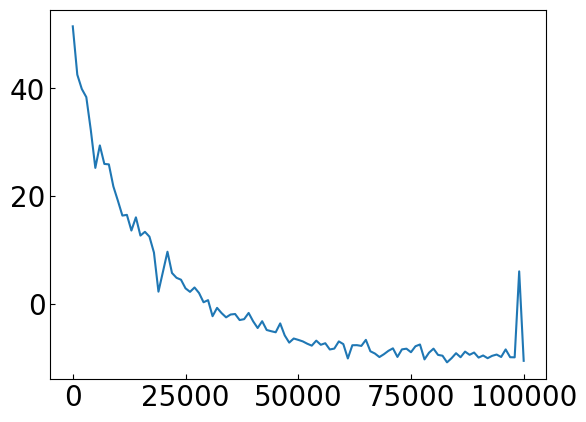

In [275]:
s11_t1 = dd_t1['s11']['values']
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [276]:
par_ini_t1 = {
    'gamma': 1/20000e-3,
    'amp':20,
    'const':-5
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [277]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1*1e-3)
result_t1

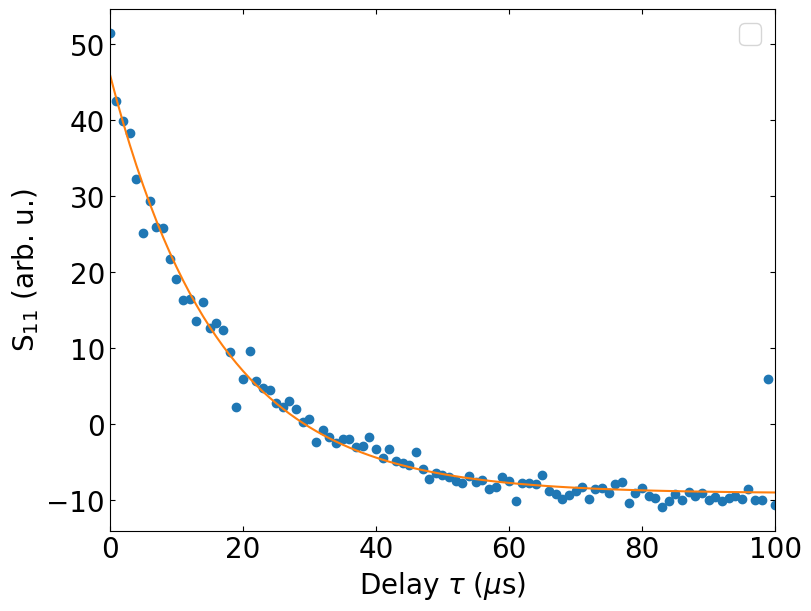

In [278]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(delay_t1,result_t1.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
ax.set_xlim(0, 100)
# plt.savefig('ef_T1.png', bbox_inches='tight')

plt.show()

In [280]:
T1 = (1/0.06149815)*1e-9	
T1

1.626065174318252e-08